In [ ]:
pip install pyqt5


In [ ]:
pip install mne autoreject

In [7]:
import numpy as np 
import matplotlib.pyplot as plt
import mne

In [8]:
raw = mne.io.read_raw_eeglab(r"sub-001_task-motion_run-3_eeg (1).set", preload=True)
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


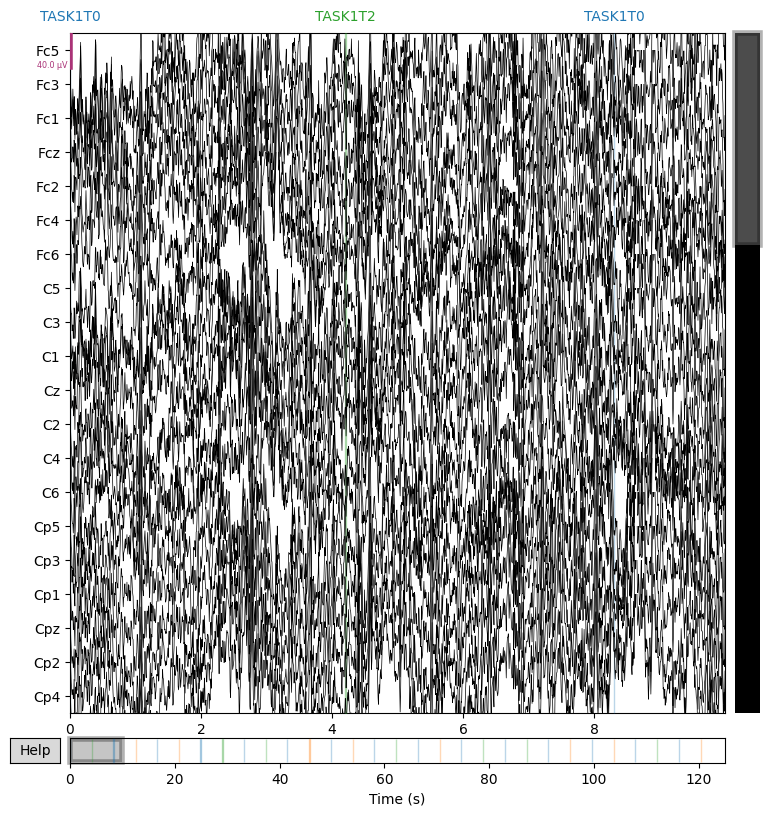

In [17]:
%matplotlib qt
raw.plot()

In [11]:
print(raw.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


In [25]:
canales_eeg = ['Fp1', 'Fp2', 'C3']


In [18]:
data, times = raw.get_data(return_times=True)
print(data.shape)
print(times.shape)

(64, 20000)
(20000,)


In [22]:
plt.plot(times, data[0])
plt.xlabel('Tiempo (s)')    
plt.ylabel('Amplitud (µV)')
plt.title('Señal EEG del canal Fp1')
plt.show()

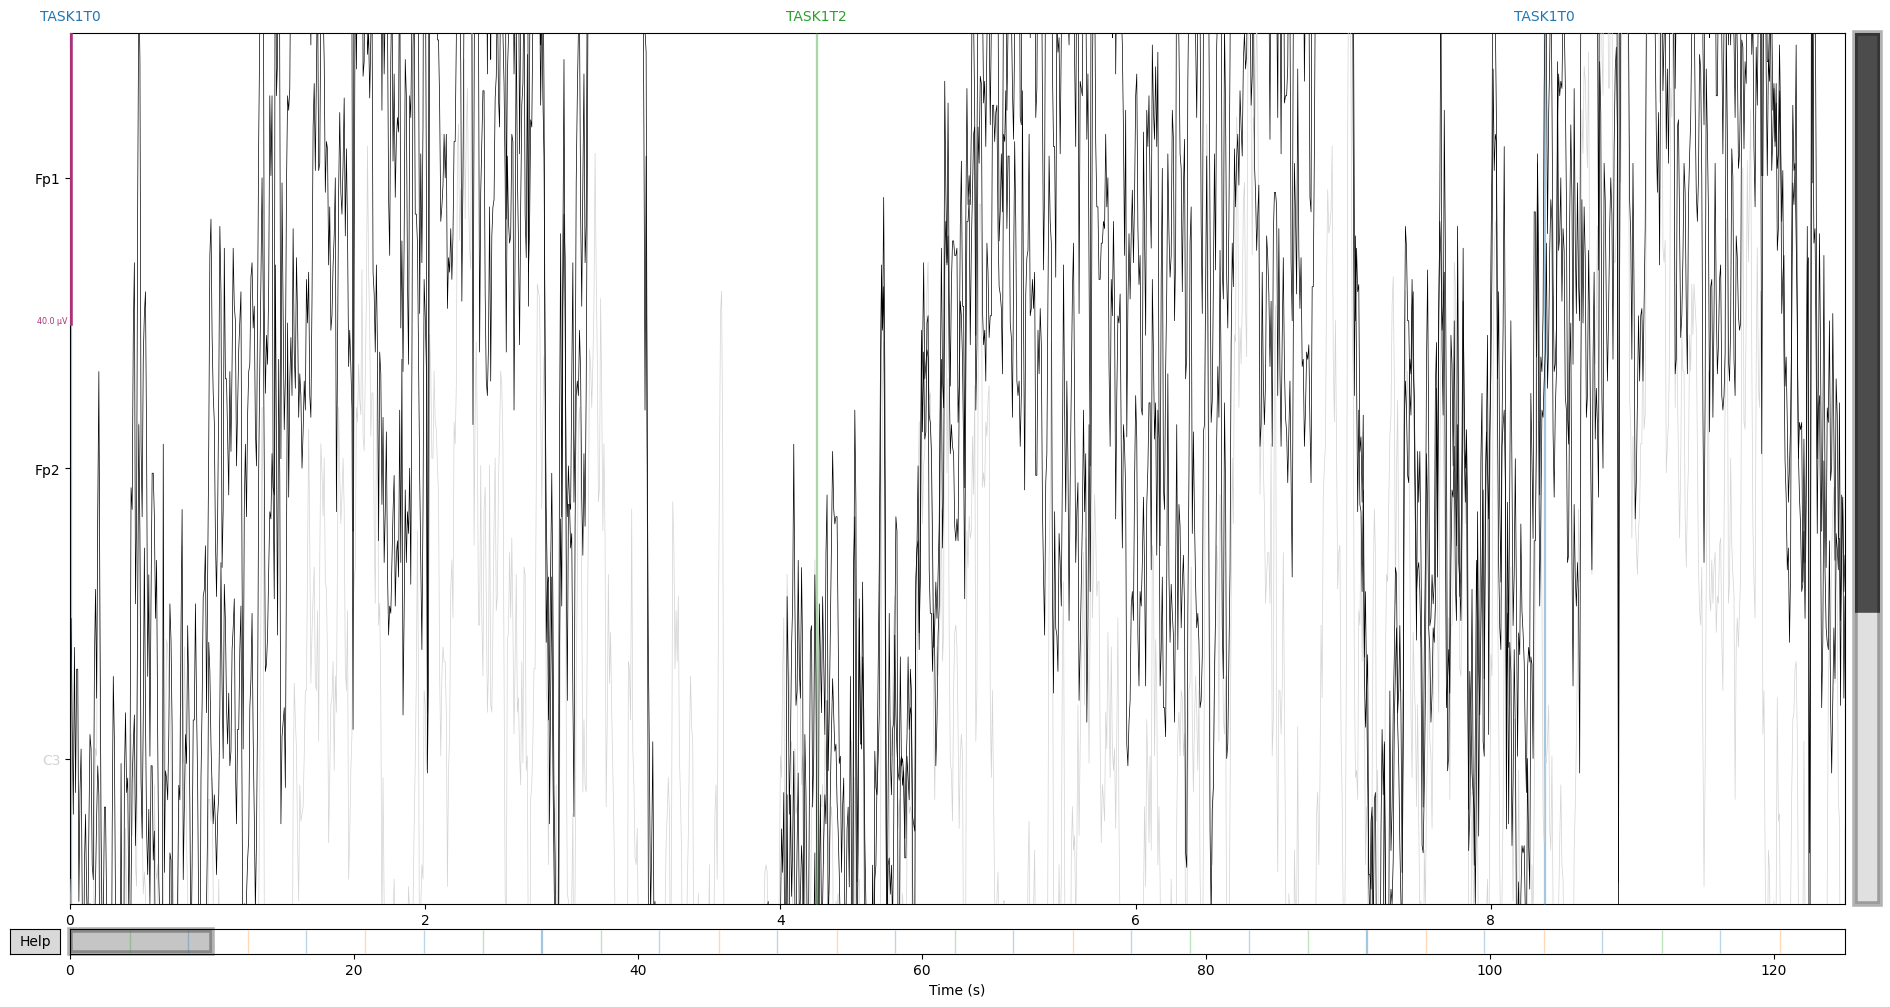

In [26]:
raw_sel = raw.copy().pick(canales_eeg)
raw_sel.plot()

In [27]:
data, times = raw_sel.get_data(return_times=True)
print(data.shape)

(3, 20000)


In [28]:
plt.figure(figsize=(10, 6))
for i in canales_eeg:
    plt.subplot(len(canales_eeg), 1, canales_eeg.index(i) + 1)
    plt.plot(times, data[canales_eeg.index(i)])
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (µV)') 
    plt.title(f'Señal EEG del canal {i}')
    plt.tight_layout()
plt.show()
